In [1]:
import numpy as np
import pandas as pd

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt

In [3]:
diabetes = load_diabetes()

X = diabetes.data
y = diabetes.target

print("Features:", diabetes.feature_names)
print("Target Name:", "Disease Progression")

print("\nFirst 10 Records:\n", X[:10])

Features: ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']
Target Name: Disease Progression

First 10 Records:
 [[ 0.03807591  0.05068012  0.06169621  0.02187239 -0.0442235  -0.03482076
  -0.04340085 -0.00259226  0.01990749 -0.01764613]
 [-0.00188202 -0.04464164 -0.05147406 -0.02632753 -0.00844872 -0.01916334
   0.07441156 -0.03949338 -0.06833155 -0.09220405]
 [ 0.08529891  0.05068012  0.04445121 -0.00567042 -0.04559945 -0.03419447
  -0.03235593 -0.00259226  0.00286131 -0.02593034]
 [-0.08906294 -0.04464164 -0.01159501 -0.03665608  0.01219057  0.02499059
  -0.03603757  0.03430886  0.02268774 -0.00936191]
 [ 0.00538306 -0.04464164 -0.03638469  0.02187239  0.00393485  0.01559614
   0.00814208 -0.00259226 -0.03198764 -0.04664087]
 [-0.09269548 -0.04464164 -0.04069594 -0.01944183 -0.06899065 -0.07928784
   0.04127682 -0.0763945  -0.04117617 -0.09634616]
 [-0.04547248  0.05068012 -0.04716281 -0.01599898 -0.04009564 -0.02480001
   0.00077881 -0.03949338 -0.06291688 -0.03835666

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print("Train Shape:", X_train.shape)
print("Test Shape:", X_test.shape)

Train Shape: (353, 10)
Test Shape: (89, 10)


In [5]:
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 42.79409467959994
MSE: 2900.193628493482
RMSE: 53.85344583676593
R2 Score: 0.4526027629719195


In [6]:
alphas = [0.1, 1, 10]

for a in alphas:
    ridge = Ridge(alpha=a)
    ridge.fit(X_train, y_train)
    pred = ridge.predict(X_test)
    print(f"\nAlpha: {a}")
    print("R2:", r2_score(y_test, pred))


Alpha: 0.1
R2: 0.46085219464119265

Alpha: 1
R2: 0.41915292635986545

Alpha: 10
R2: 0.161225867509881


In [7]:
lasso = Lasso(alpha=0.1)
lasso.fit(X_train, y_train)

print("Lasso Coefficients:\n", lasso.coef_)

Lasso Coefficients:
 [   0.         -152.66477923  552.69777529  303.36515791  -81.36500664
   -0.         -229.25577639    0.          447.91952518   29.64261704]


In [8]:
elastic = ElasticNet(alpha=0.1, l1_ratio=0.5)
elastic.fit(X_train, y_train)

y_pred_en = elastic.predict(X_test)

print("ElasticNet R2:", r2_score(y_test, y_pred_en))

ElasticNet R2: 0.09865421116113748


In [9]:
coef_df = pd.DataFrame({
    "Feature": diabetes.feature_names,
    "Linear": lr.coef_,
    "Ridge": Ridge(alpha=1).fit(X_train, y_train).coef_,
    "Lasso": lasso.coef_,
    "ElasticNet": elastic.coef_
})

print(coef_df)

  Feature      Linear       Ridge       Lasso  ElasticNet
0     age   37.904021   45.367377    0.000000   10.830921
1     sex -241.964362  -76.666086 -152.664779   -0.009514
2     bmi  542.428759  291.338832  552.697775   38.906865
3      bp  347.703844  198.995817  303.365158   28.779233
4      s1 -931.488846   -0.530310  -81.365007   10.372007
5      s2  518.062277  -28.577050   -0.000000    7.191892
6      s3  163.419983 -144.511905 -229.255776  -23.510979
7      s4  275.317902  119.260066    0.000000   25.627160
8      s5  736.198859  230.221608  447.919525   35.073745
9      s6   48.670657  112.149830   29.642617   24.071251


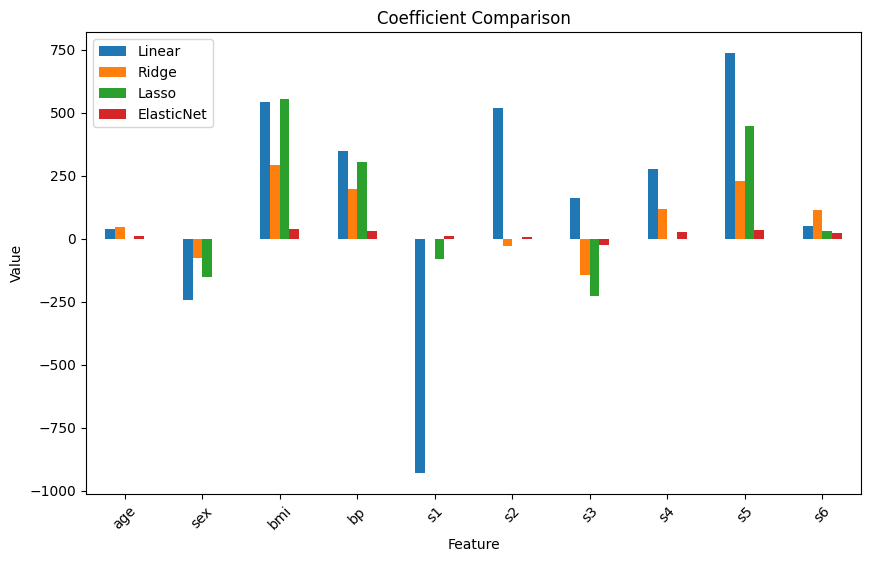

In [10]:
coef_df.set_index("Feature").plot(kind="bar", figsize=(10,6))
plt.title("Coefficient Comparison")
plt.ylabel("Value")
plt.xticks(rotation=45)
plt.show()

In [11]:
# Conclusion:
# Linear Regression provides a basic model, but may overfit.
# Ridge reduces overfitting by shrinking coefficients,
# Lasso performs feature selection by making some coefficients zero,
# and ElasticNet combines both methods for better balance.
# The choice depends on data complexity and feature importance.